In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Set device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Sliding window parameters
window_size = 128
step_size = 64
selected_labels = ['Walking', 'Jogging', 'Sitting', 'Standing']


Using device: mps


In [6]:

# 1. Preprocessing
def preprocess_data(file_path):
    df = pd.read_csv(file_path)
    df = df[df['activity'].isin(selected_labels)]
    df = df.sort_values(['user', 'timestamp'])

    le = LabelEncoder()
    df['label'] = le.fit_transform(df['activity'])
    label_map = dict(zip(le.classes_, le.transform(le.classes_)))
    print("Label map:", label_map)

    segments = []
    labels = []
    for user in df['user'].unique():
        user_df = df[df['user'] == user]
        for start in range(0, len(user_df) - window_size, step_size):
            window = user_df.iloc[start:start + window_size]
            if len(window) == window_size:
                segment = window[['x-axis', 'y-axis', 'z-axis']].values
                label = Counter(window['label']).most_common(1)[0][0]
                segments.append(segment)
                labels.append(label)

    X = np.array(segments)
    y = np.array(labels)
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return X, y



In [7]:
# 2. Dataset Class
class ActivityDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32).permute(0, 2, 1).to(device)
        self.labels = torch.tensor(labels, dtype=torch.long).to(device)
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]



In [8]:
# 3. CNN Model
class ActivityCNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(ActivityCNN, self).__init__()
        
        self.conv1 = nn.Conv1d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1)
        
        self.feature_size = input_size // 4
        
        self.fc1 = nn.Linear(64 * self.feature_size, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool1d(x, 2)
        
        x = F.relu(self.conv2(x))
        x = F.max_pool1d(x, 2)
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# 4. Load and preprocess data
data_path = "time_series_data_human_activities.csv"
X, y = preprocess_data(data_path)
num_classes = len(set(y))
input_size = X.shape[1]

# 5. Create dataset and dataloaders
dataset = ActivityDataset(X, y)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42)
)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


Label map: {'Jogging': 0, 'Sitting': 1, 'Standing': 2, 'Walking': 3}
X shape: (13240, 128, 3)
y shape: (13240,)


In [9]:

# 6. Initialize and train CNN model
model = ActivityCNN(input_size, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total
        train_losses.append(train_loss)
        
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = correct / total
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{epochs} - Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} - Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")
    
    return train_losses, val_losses

print("Training CNN model...")
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)


Training CNN model...
Epoch 1/10 - Train loss: 0.2569, Train acc: 0.9200 - Val loss: 0.0782, Val acc: 0.9829
Epoch 2/10 - Train loss: 0.0726, Train acc: 0.9815 - Val loss: 0.0528, Val acc: 0.9884
Epoch 3/10 - Train loss: 0.0549, Train acc: 0.9855 - Val loss: 0.0442, Val acc: 0.9884
Epoch 4/10 - Train loss: 0.0472, Train acc: 0.9873 - Val loss: 0.0478, Val acc: 0.9874
Epoch 5/10 - Train loss: 0.0364, Train acc: 0.9896 - Val loss: 0.0369, Val acc: 0.9904
Epoch 6/10 - Train loss: 0.0301, Train acc: 0.9903 - Val loss: 0.0408, Val acc: 0.9904
Epoch 7/10 - Train loss: 0.0226, Train acc: 0.9928 - Val loss: 0.0349, Val acc: 0.9899
Epoch 8/10 - Train loss: 0.0210, Train acc: 0.9930 - Val loss: 0.0596, Val acc: 0.9849
Epoch 9/10 - Train loss: 0.0170, Train acc: 0.9943 - Val loss: 0.0346, Val acc: 0.9909
Epoch 10/10 - Train loss: 0.0220, Train acc: 0.9926 - Val loss: 0.0274, Val acc: 0.9924



Evaluating CNN model on test data...
Test Accuracy: 0.9950

Classification Report:
              precision    recall  f1-score   support

     Walking       1.00      1.00      1.00       763
     Jogging       0.99      0.99      0.99       140
     Sitting       0.99      0.98      0.99       114
    Standing       1.00      1.00      1.00       969

    accuracy                           0.99      1986
   macro avg       0.99      0.99      0.99      1986
weighted avg       0.99      0.99      0.99      1986



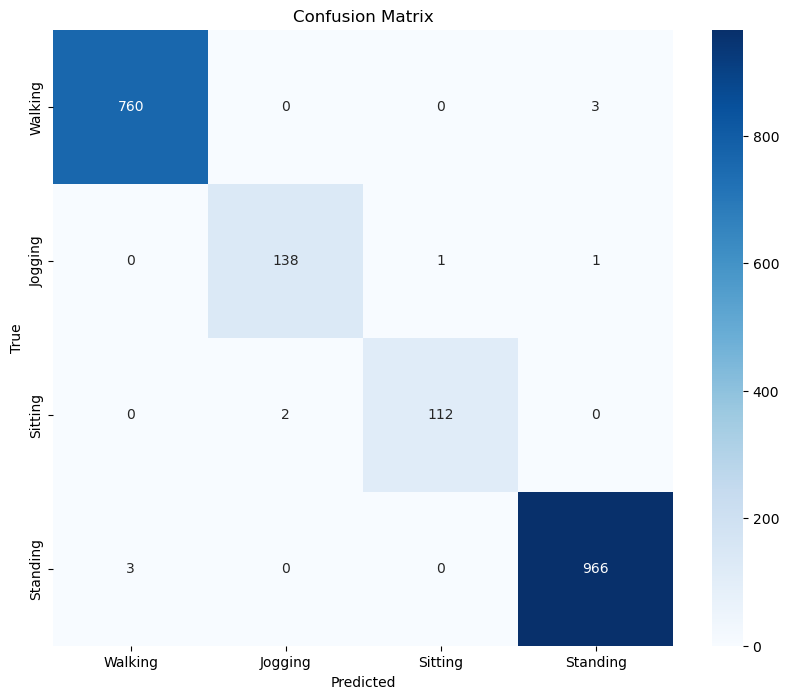

In [10]:

# 7. Evaluate CNN model
def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    cm = confusion_matrix(all_labels, all_preds)
    
    print(f"Test Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=selected_labels))
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=selected_labels, yticklabels=selected_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    
    return accuracy, cm

print("\nEvaluating CNN model on test data...")
accuracy, cm = evaluate_model(model, test_loader, selected_labels)


/Users/janeyan/miniforge3/envs/dasc_5410/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 126, 64)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,144 (301.34 KB)

 Trainable params: 77,144 (301.34 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN + LSTM model...
Epoch 1/10


2025-04-13 11:45:32.587576: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8113 - loss: 0.5188 - val_accuracy: 0.9830 - val_loss: 0.0671
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9831 - loss: 0.0679 - val_accuracy: 0.9891 - val_loss: 0.0507
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9818 - loss: 0.0689 - val_accuracy: 0.9877 - val_loss: 0.0438
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9881 - loss: 0.0462 - val_accuracy: 0.9882 - val_loss: 0.0544
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9881 - loss: 0.0524 - val_accuracy: 0.9764 - val_loss: 0.0792
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9797 - loss: 0.0633 - val_accuracy: 0.9891 - val_loss: 0.0426
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9915 - loss: 0.0362 - val_accuracy: 0.9877 - val_loss: 0.0588
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9857 - loss: 0.0562 - val_accuracy: 0.980

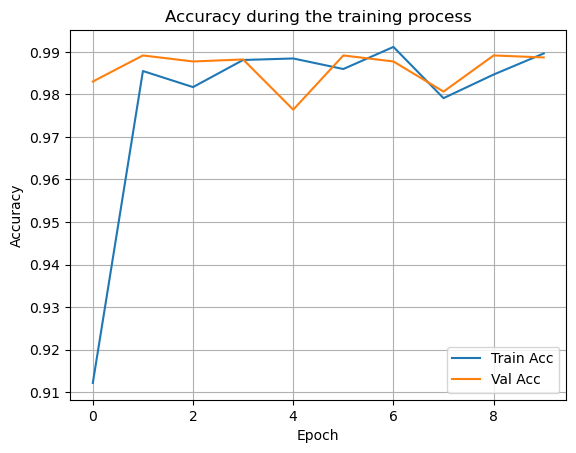

83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Classification Report for CNN + LSTM model:
              precision    recall  f1-score   support

     Walking       1.00      0.98      0.99       980
     Jogging       0.99      0.96      0.98       172
     Sitting       0.95      1.00      0.98       143
    Standing       0.99      1.00      0.99      1353

    accuracy                           0.99      2648
   macro avg       0.98      0.98      0.98      2648
weighted avg       0.99      0.99      0.99      2648



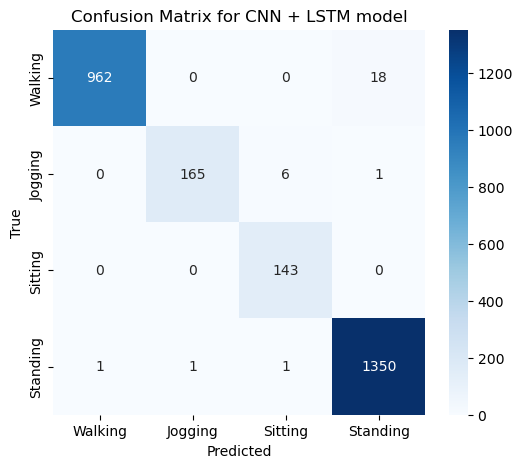

In [11]:

# 8. CNN + LSTM Model
X_train, X_test, y_train, y_test = train_test_split(X, to_categorical(y), test_size=0.2, random_state=42)

cnn_lstm_model = Sequential()
cnn_lstm_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(128, 3)))
cnn_lstm_model.add(MaxPooling1D(pool_size=2))
cnn_lstm_model.add(Dropout(0.3))

cnn_lstm_model.add(LSTM(100))
cnn_lstm_model.add(Dropout(0.3))

cnn_lstm_model.add(Dense(100, activation='relu'))
cnn_lstm_model.add(Dense(4, activation='softmax'))

cnn_lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
cnn_lstm_model.summary()

# Train CNN + LSTM model
print("\nTraining CNN + LSTM model...")
history = cnn_lstm_model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Visualize training process
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy during the training process")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Prediction and evaluation for CNN + LSTM model
y_pred = cnn_lstm_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report for CNN + LSTM model:")
print(classification_report(y_true, y_pred_classes, target_names=selected_labels))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=selected_labels, yticklabels=selected_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for CNN + LSTM model')
plt.show()
